
#***Customer Churn Prediction***

#***🧠 Problem Statement***
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:
#● Customer Age
#● Gender
#● Tenure
#● Contract Type
#● Payment Method
#● Internet Service
#● Tech Support
#● Online Security
#● Customer Support Calls
Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

##***🎯 Objective***
The objective of this task is to:
● Understand and explore the customer dataset
● Perform data preprocessing (missing values, duplicates, outliers)
● Conduct Exploratory Data Analysis (EDA)
● Apply encoding and feature scaling
● Train multiple classification algorithms
● Evaluate models using classification metrics
● Perform cross-validation and hyperparameter tuning
● Select the best-performing model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv("telecom_churn_data.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.drop("customerID",axis=1,inplace=True)

In [10]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [11]:
df.isnull().sum()

,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [12]:
#gender
df["gender"]=df["gender"].fillna(df["gender"].mode()[0])

In [13]:
df["PaperlessBilling"]=df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0])

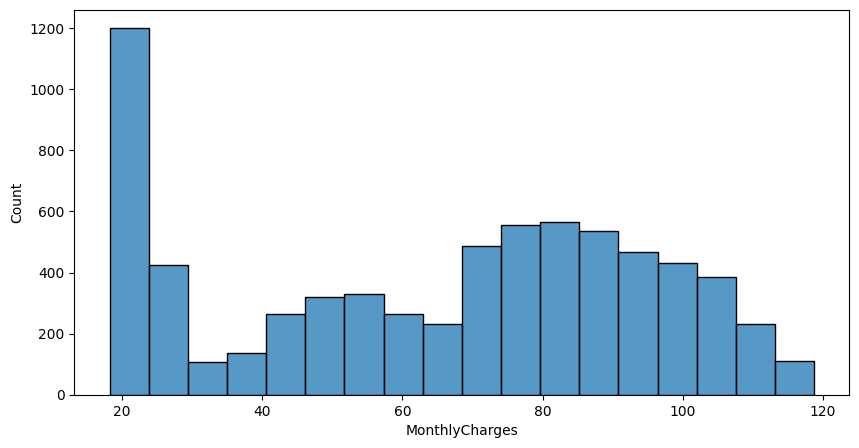

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df,x="MonthlyCharges")
plt.show()

In [15]:
df["MonthlyCharges"].skew()

np.float64(-0.22028439456532767)

In [16]:
df['MonthlyCharges']=df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


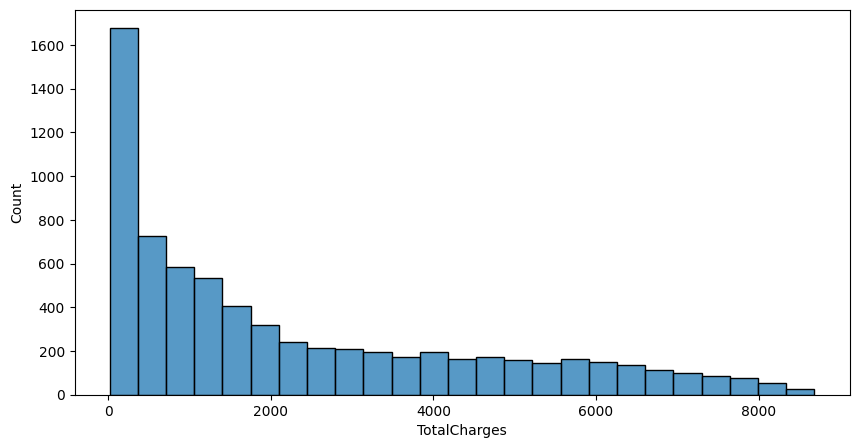

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df,x="TotalCharges")
plt.show()

In [19]:
df['TotalCharges'].skew()

np.float64(0.9616058347613503)

In [20]:
df['TotalCharges']=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [21]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [22]:
df.duplicated().sum()

np.int64(22)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
num_cols=df.select_dtypes(include=['int64','float64'])
cat_cols=df.select_dtypes(include=['object'])

In [25]:
num_cols

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [26]:
cat_cols

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


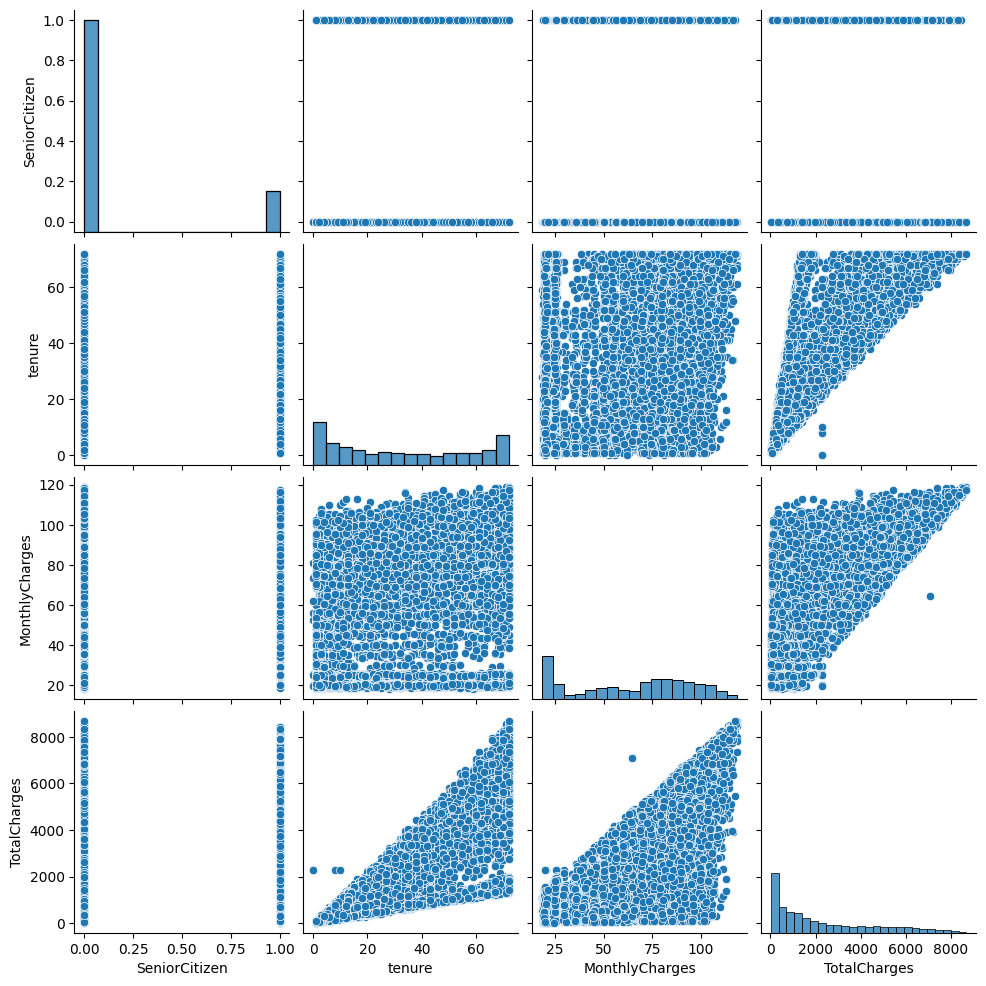

In [27]:
#EDA
sns.pairplot(df)
plt.show()

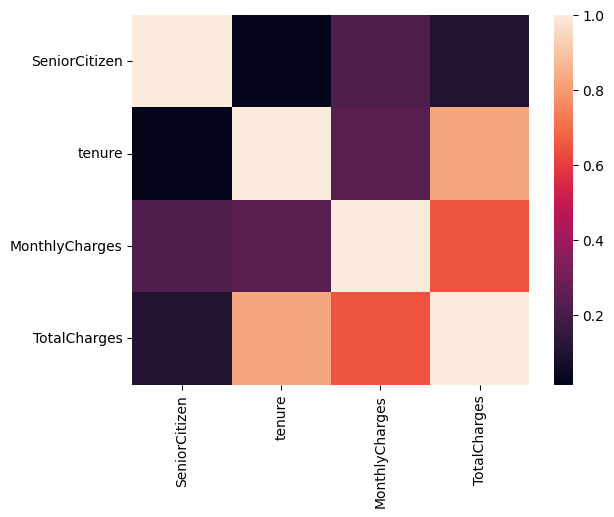

In [28]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

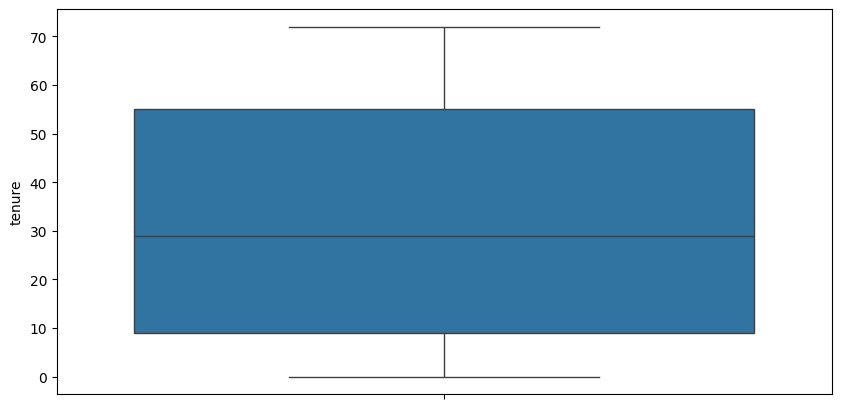

In [29]:
#check for outliers
#tenure
#monthlycharges
#totalcharges
plt.figure(figsize=(10,5))
sns.boxplot(df["tenure"])
plt.show()

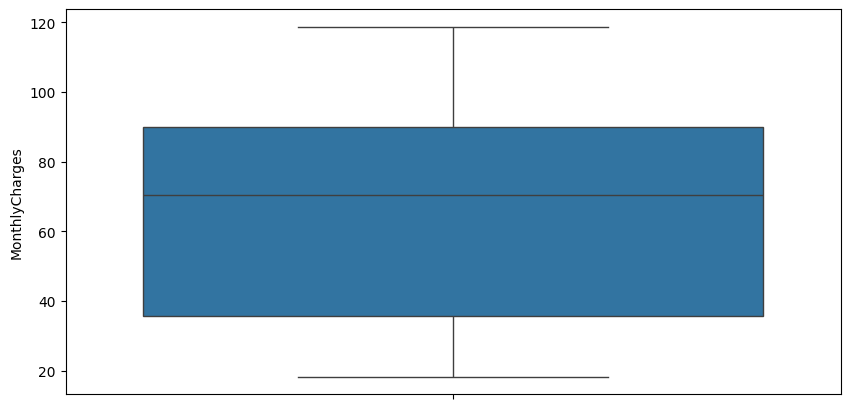

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(df["MonthlyCharges"])
plt.show()

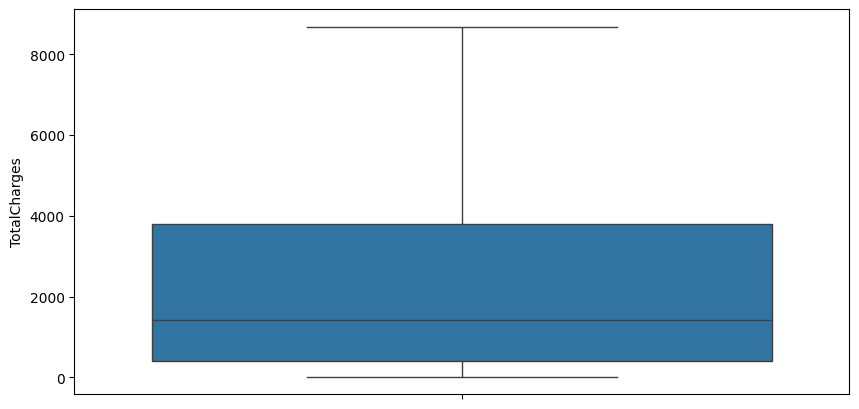

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(df["TotalCharges"])
plt.show()


In [32]:
#no outliers

In [33]:
df=pd.get_dummies(df,columns=['gender'],dtype='int')

In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['partner']=le.fit_transform(df['Partner'])
df['dependents']=le.fit_transform(df['Dependents'])
df['phoneService']=le.fit_transform(df['PhoneService'])
df['onlineSecurity']=le.fit_transform(df['OnlineSecurity'])
df['onlineBackup']=le.fit_transform(df['OnlineBackup'])
df['deviceProtection']=le.fit_transform(df['DeviceProtection'])
df['techSupport']=le.fit_transform(df['TechSupport'])
df['streamingTV']=le.fit_transform(df['StreamingTV'])
df['streamingMovies']=le.fit_transform(df['StreamingMovies'])
df['paperlessBilling']=le.fit_transform(df['PaperlessBilling'])
df['churn']=le.fit_transform(df['Churn'])

In [35]:
df.drop(columns=["Partner",'Dependents','PhoneService','OnlineBackup','OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn'],axis=1,inplace=True)

In [36]:
df.head()

,SeniorCitizen,tenure,MultipleLines,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,gender_Female,gender_Male,...,dependents,phoneService,onlineSecurity,onlineBackup,deviceProtection,techSupport,streamingTV,streamingMovies,paperlessBilling,churn
0,0,1,No phone service,DSL,Month-to-month,Electronic check,29.85,29.85,1,0,...,0,0,0,2,0,0,0,0,1,0
1,0,34,No,DSL,One year,Mailed check,56.95,1889.50,0,1,...,0,1,2,0,2,0,0,0,0,0
2,0,2,No,DSL,Month-to-month,Mailed check,53.85,108.15,0,1,...,0,1,2,2,0,0,0,0,1,1
3,0,45,No phone service,DSL,One year,Bank transfer (automatic),42.30,1840.75,0,1,...,0,0,2,0,2,2,0,0,0,0
4,0,2,No,Fiber optic,Month-to-month,Electronic check,70.70,151.65,1,0,...,0,1,0,0,0,0,0,0,1,1


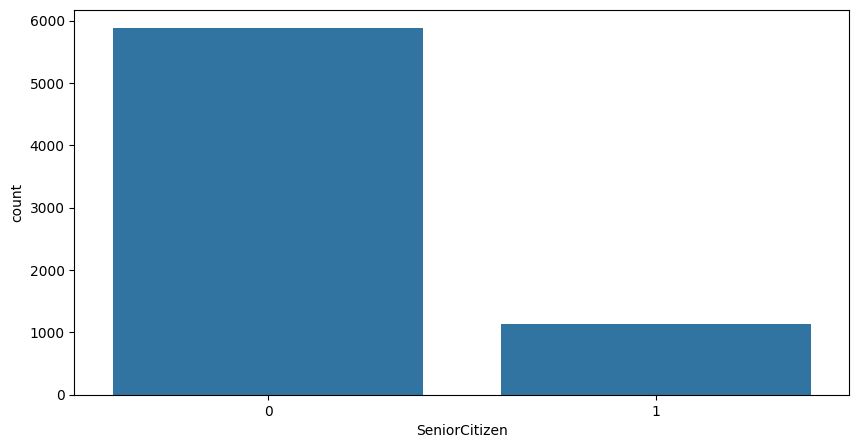

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='SeniorCitizen')
plt.show()

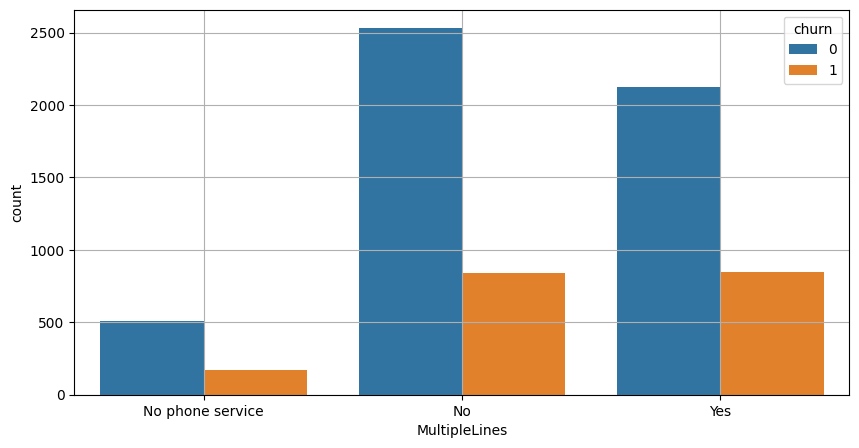

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='MultipleLines',hue='churn')
plt.grid()
plt.show()

In [39]:
df['multipleLines']=df['MultipleLines'].map({'No phone service':0,'Yes':2,'No':1})

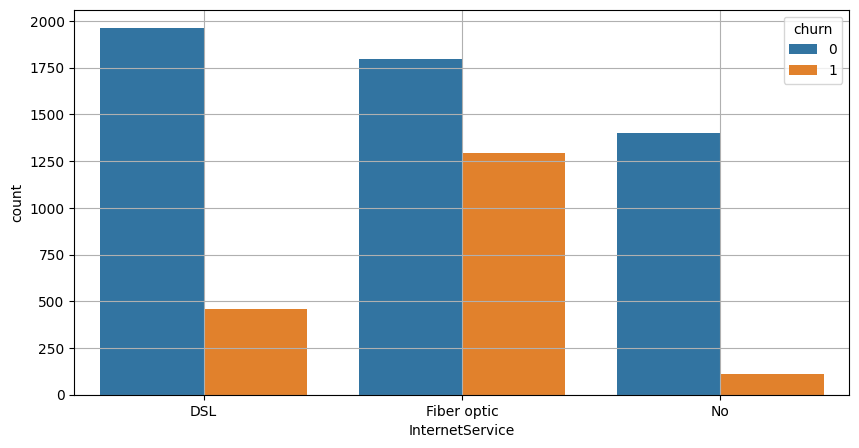

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='InternetService',hue='churn')
plt.grid()
plt.show()

In [41]:
df['internetservice']=df['InternetService'].map({'Fiber optic':2,'DSL':1,'No':0})


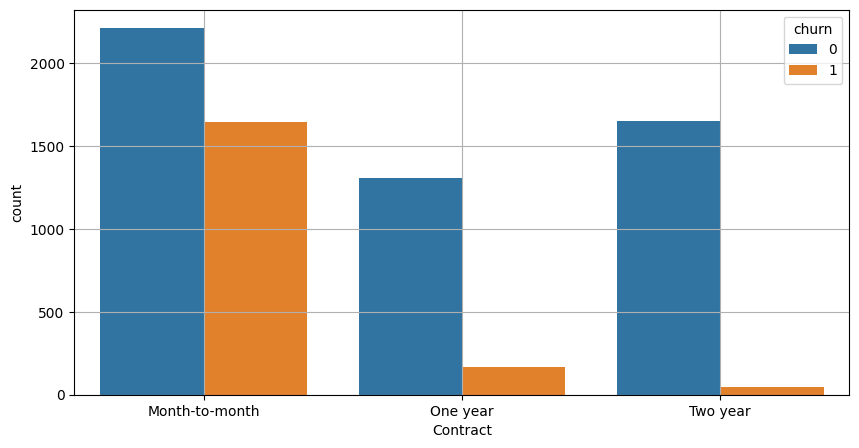

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='Contract',hue='churn')
plt.grid()
plt.show()

In [43]:
df['contract']=df['Contract'].map({'Month-to-month':2,'One year':1,'Two year':0})

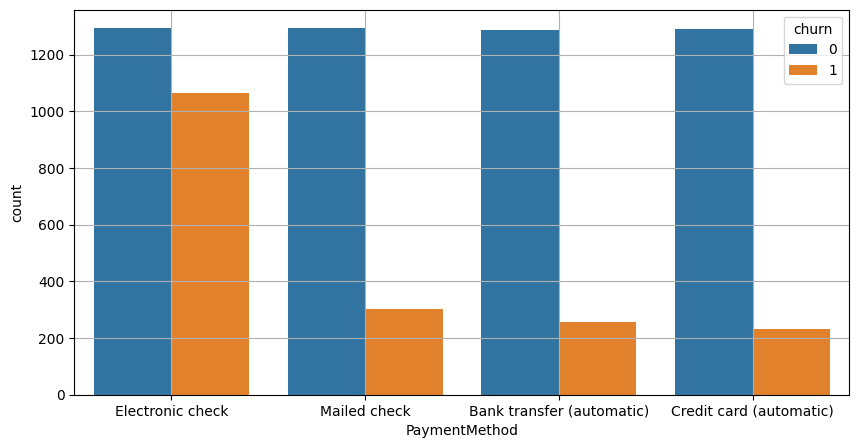

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(df,x='PaymentMethod',hue='churn')
plt.grid()
plt.show()

In [45]:
df['paymentmethod']=df['PaymentMethod'].map({'Electronic check':3,'Mailed check':2,'Bank transfer (automatic)':1,'Credit card (automatic)':0})

In [46]:
df.drop(columns=['MultipleLines','InternetService','Contract','PaymentMethod'],axis=1,inplace=True)

In [47]:
df.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
gender_Female,0
gender_Male,0
partner,0
dependents,0
phoneService,0
onlineSecurity,0


In [48]:
from sklearn.preprocessing import StandardScaler
model=StandardScaler()
df['tenure']=model.fit_transform(df[['tenure']])
df['MonthlyCharges']=model.fit_transform(df[['MonthlyCharges']])
df['TotalCharges']=model.fit_transform(df[['TotalCharges']])

In [49]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,partner,dependents,phoneService,onlineSecurity,...,deviceProtection,techSupport,streamingTV,streamingMovies,paperlessBilling,churn,multipleLines,internetservice,contract,paymentmethod
0,0,-1.282728,-1.164064,-0.998262,1,0,1,0,0,0,...,0,0,0,0,1,0,0,1,2,3
1,0,0.062387,-0.262482,-0.177063,0,1,0,0,1,2,...,2,0,0,0,0,0,1,1,1,2
2,0,-1.241967,-0.365615,-0.963686,0,1,0,0,1,2,...,0,0,0,0,1,1,1,1,2,2
3,0,0.510759,-0.749868,-0.198591,0,1,0,0,0,2,...,2,2,0,0,0,0,0,1,1,1
4,0,-1.241967,0.194963,-0.944477,1,0,0,0,1,0,...,0,0,0,0,1,1,1,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,-0.345224,0.664052,-0.132463,0,1,1,1,1,2,...,2,2,2,2,1,0,2,1,1,2
7039,0,1.611307,1.276196,2.239924,1,0,1,1,1,0,...,2,0,2,2,1,0,2,2,1,0
7040,0,-0.875118,-1.172381,-0.858455,1,0,1,1,0,2,...,0,0,0,0,1,0,0,1,2,3
7041,1,-1.160445,0.318057,-0.876053,0,1,1,0,1,0,...,0,0,0,0,1,1,2,2,2,2


In [50]:
#split tha data
from sklearn.model_selection import train_test_split

x=df.drop('churn',axis=1)
y=df['churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

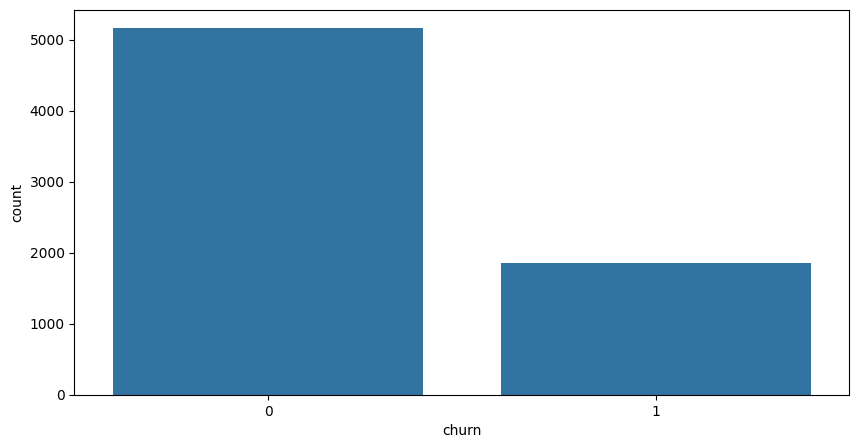

In [51]:
#balancing the data
plt.figure(figsize=(10,5))
sns.countplot(df,x='churn')
plt.show()

In [52]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_train_s,y_train_s=smote.fit_resample(x_train,y_train)

In [53]:
#before sampling
from collections import Counter
Counter(y_train)

Counter({1: 1505, 0: 4111})

In [54]:
#after sampling
from collections import Counter
Counter(y_train_s)

Counter({1: 4111, 0: 4111})

#logistic regression model

In [55]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy: 0.7395
Precision: 0.4872
Recall: 0.7557
F1-Score: 0.5924


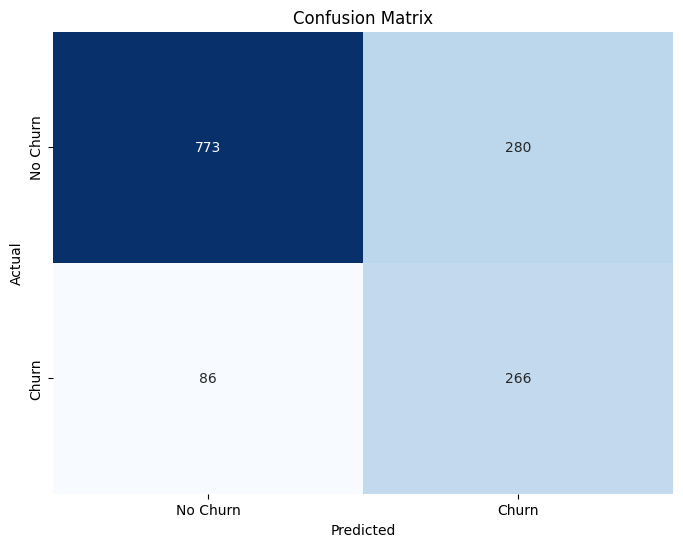

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#KNN model

In [57]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)


Accuracy (KNN): 0.6989
Precision (KNN): 0.4353
Recall (KNN): 0.6790
F1-Score (KNN): 0.5305


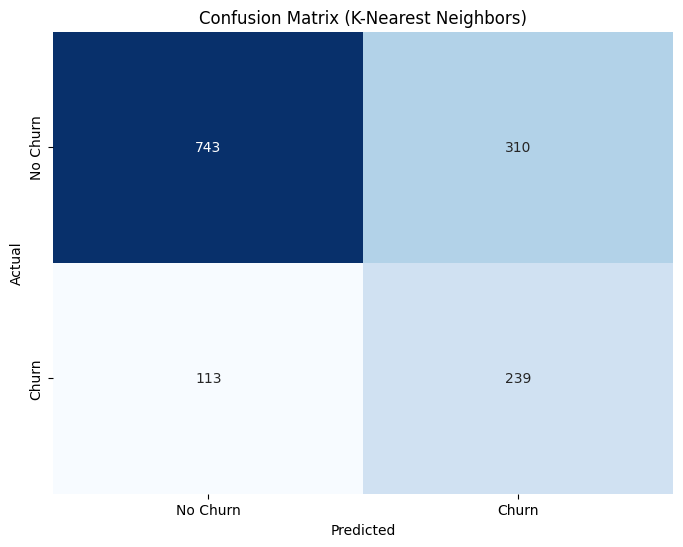

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred)
recall_knn = recall_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred)
conf_matrix_knn = confusion_matrix(y_test, y_pred)

print(f"Accuracy (KNN): {accuracy_knn:.4f}")
print(f"Precision (KNN): {precision_knn:.4f}")
print(f"Recall (KNN): {recall_knn:.4f}")
print(f"F1-Score (KNN): {f1_knn:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (K-Nearest Neighbors)')
plt.show()

#**decisiontree classifier**

In [59]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy (Decision Tree): 0.7025
Precision (Decision Tree): 0.4289
Recall (Decision Tree): 0.5653
F1-Score (Decision Tree): 0.4877


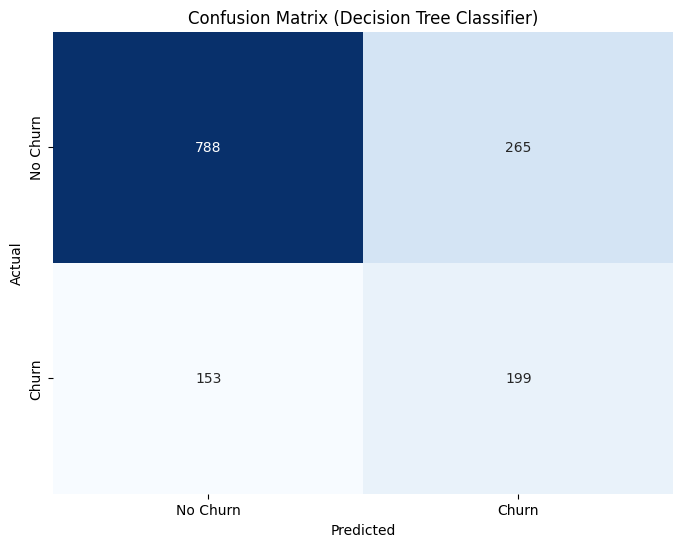

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred)
recall_dt = recall_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)
conf_matrix_dt = confusion_matrix(y_test, y_pred)

print(f"Accuracy (Decision Tree): {accuracy_dt:.4f}")
print(f"Precision (Decision Tree): {precision_dt:.4f}")
print(f"Recall (Decision Tree): {recall_dt:.4f}")
print(f"F1-Score (Decision Tree): {f1_dt:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Decision Tree Classifier)')
plt.show()

#**RandomForesrClassifier

In [61]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy (Random Forest): 0.7573
Precision (Random Forest): 0.5127
Recall (Random Forest): 0.6307
F1-Score (Random Forest): 0.5656


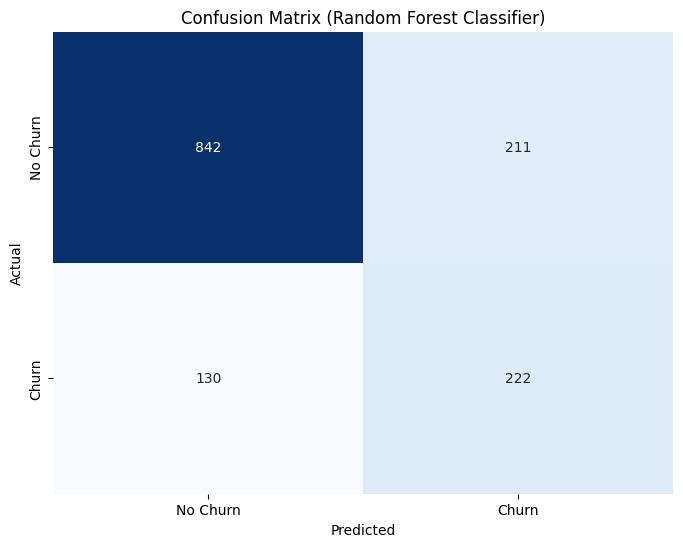

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)
conf_matrix_rf = confusion_matrix(y_test, y_pred)

print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1-Score (Random Forest): {f1_rf:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

#**Gradient boosting**

In [63]:
from sklearn.ensemble import GradientBoostingClassifier
model=GradientBoostingClassifier()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy (Gradient Boosting): 0.7459
Precision (Gradient Boosting): 0.4952
Recall (Gradient Boosting): 0.7330
F1-Score (Gradient Boosting): 0.5911


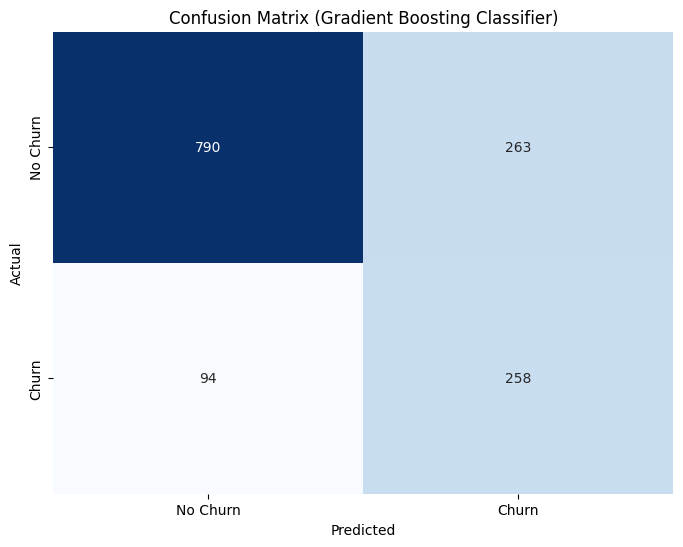

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_gb = accuracy_score(y_test, y_pred)
precision_gb = precision_score(y_test, y_pred)
recall_gb = recall_score(y_test, y_pred)
f1_gb = f1_score(y_test, y_pred)
conf_matrix_gb = confusion_matrix(y_test, y_pred)

print(f"Accuracy (Gradient Boosting): {accuracy_gb:.4f}")
print(f"Precision (Gradient Boosting): {precision_gb:.4f}")
print(f"Recall (Gradient Boosting): {recall_gb:.4f}")
print(f"F1-Score (Gradient Boosting): {f1_gb:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Gradient Boosting Classifier)')
plt.show()

#*** XGBClassifier**

In [65]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy (XGBoost): 0.7431
Precision (XGBoost): 0.4897
Recall (XGBoost): 0.6080
F1-Score (XGBoost): 0.5425


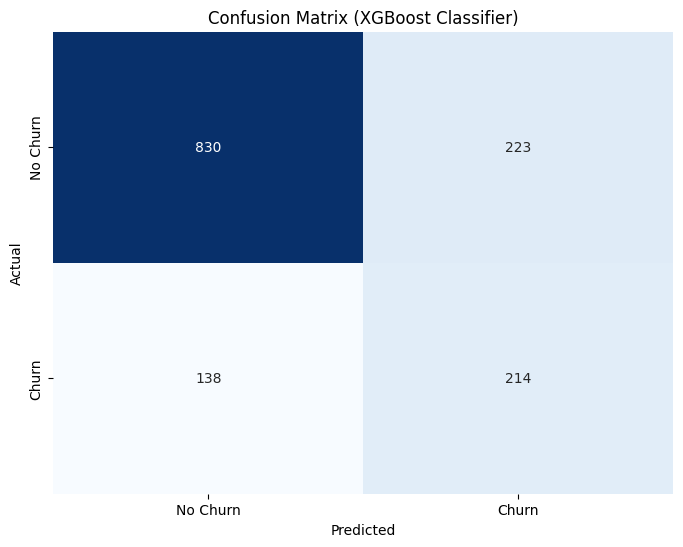

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_xgb = accuracy_score(y_test, y_pred)
precision_xgb = precision_score(y_test, y_pred)
recall_xgb = recall_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)
conf_matrix_xgb = confusion_matrix(y_test, y_pred)

print(f"Accuracy (XGBoost): {accuracy_xgb:.4f}")
print(f"Precision (XGBoost): {precision_xgb:.4f}")
print(f"Recall (XGBoost): {recall_xgb:.4f}")
print(f"F1-Score (XGBoost): {f1_xgb:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost Classifier)')
plt.show()

#***Svc**

In [67]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train_s,y_train_s)
y_pred=model.predict(x_test)

Accuracy (SVC): 0.7509
Precision (SVC): 0.5020
Recall (SVC): 0.7244
F1-Score (SVC): 0.5930


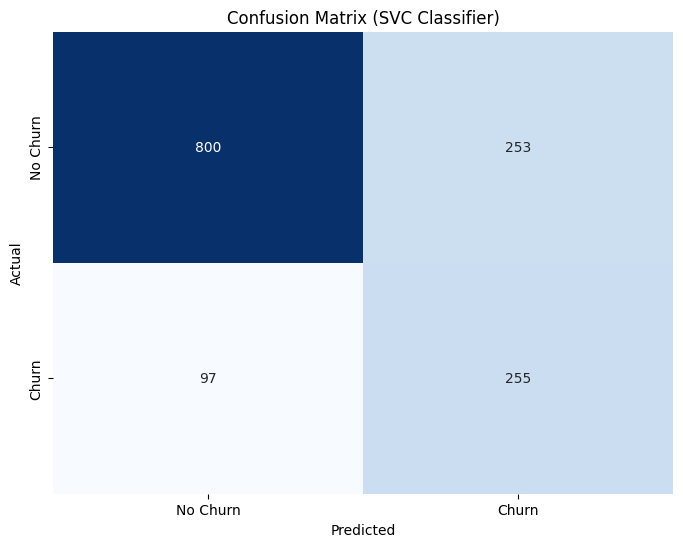

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_svc = accuracy_score(y_test, y_pred)
precision_svc = precision_score(y_test, y_pred)
recall_svc = recall_score(y_test, y_pred)
f1_svc = f1_score(y_test, y_pred)
conf_matrix_svc = confusion_matrix(y_test, y_pred)

print(f"Accuracy (SVC): {accuracy_svc:.4f}")
print(f"Precision (SVC): {precision_svc:.4f}")
print(f"Recall (SVC): {recall_svc:.4f}")
print(f"F1-Score (SVC): {f1_svc:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SVC Classifier)')
plt.show()

### Logistic Regression: ROC Curve and AUC Score

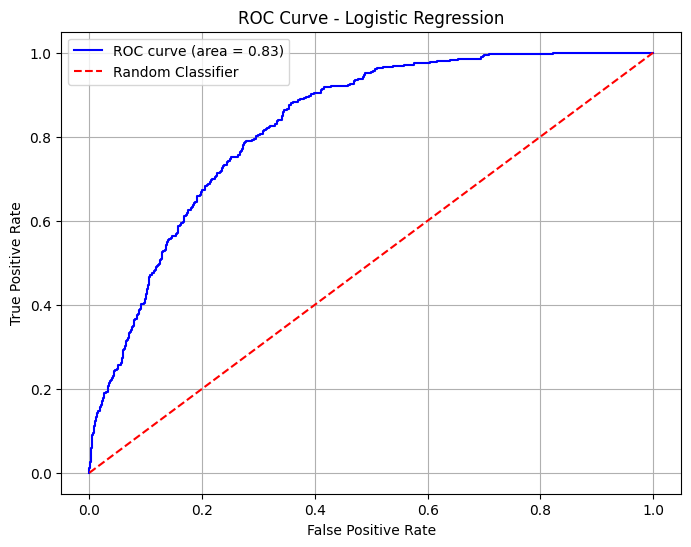

ROC AUC Score (Logistic Regression): 0.8288


In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'ROC curve (area = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (Logistic Regression): {auc_lr:.4f}")

### K-Nearest Neighbors: ROC Curve and AUC Score

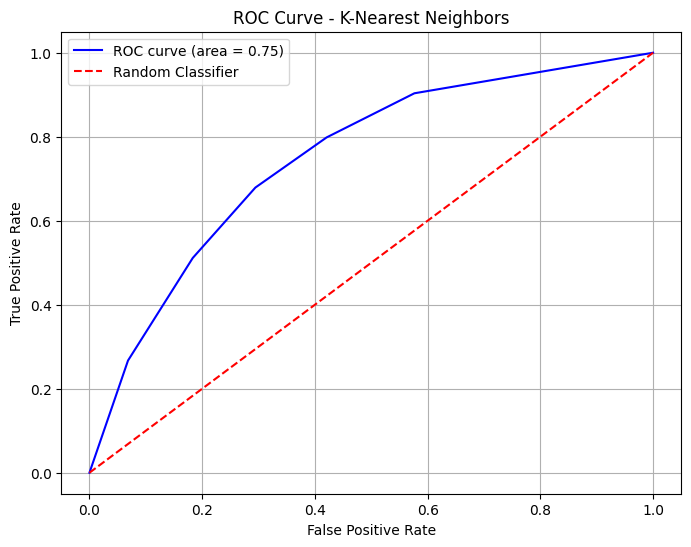

ROC AUC Score (K-Nearest Neighbors): 0.7489


In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', label=f'ROC curve (area = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (K-Nearest Neighbors): {auc_knn:.4f}")

### Decision Tree Classifier: ROC Curve and AUC Score

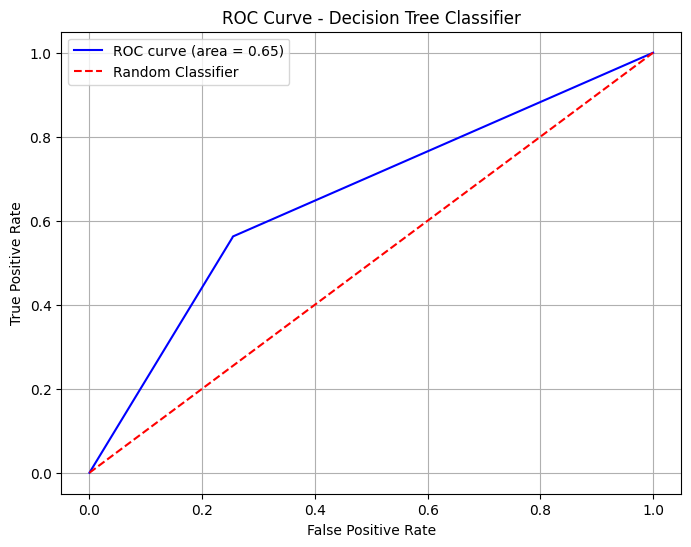

ROC AUC Score (Decision Tree Classifier): 0.6539


In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='blue', label=f'ROC curve (area = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (Decision Tree Classifier): {auc_dt:.4f}")

### Random Forest Classifier: ROC Curve and AUC Score

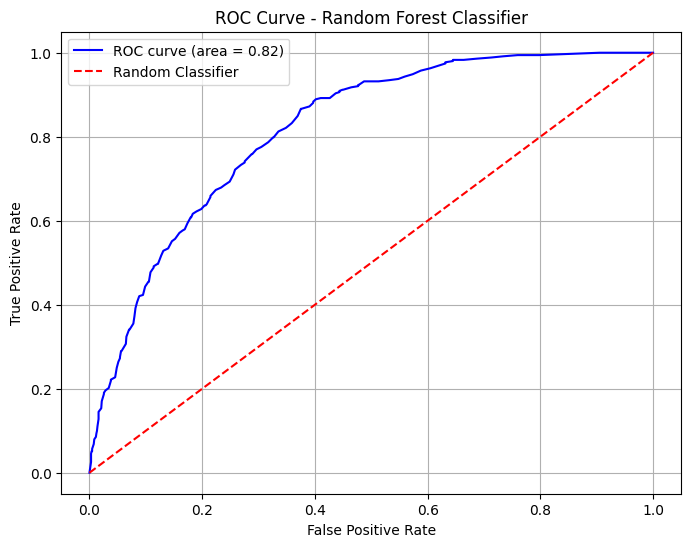

ROC AUC Score (Random Forest Classifier): 0.8160


In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (Random Forest Classifier): {auc_rf:.4f}")

### Gradient Boosting Classifier: ROC Curve and AUC Score

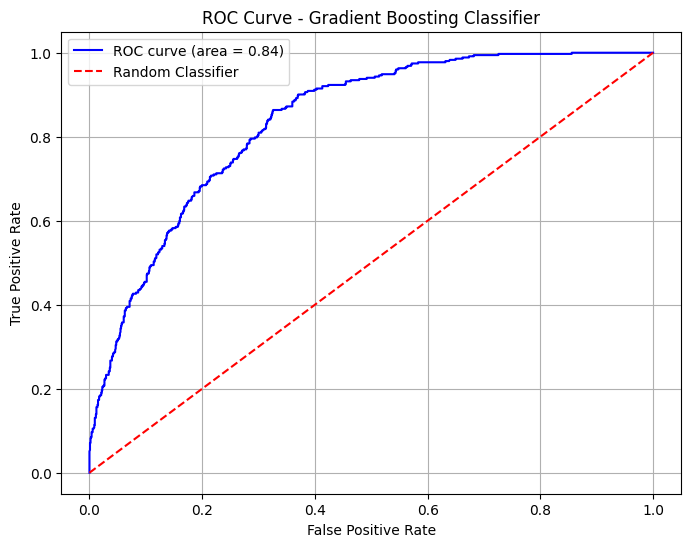

ROC AUC Score (Gradient Boosting Classifier): 0.8363


In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, color='blue', label=f'ROC curve (area = {auc_gb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting Classifier')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (Gradient Boosting Classifier): {auc_gb:.4f}")

### XGBoost Classifier: ROC Curve and AUC Score

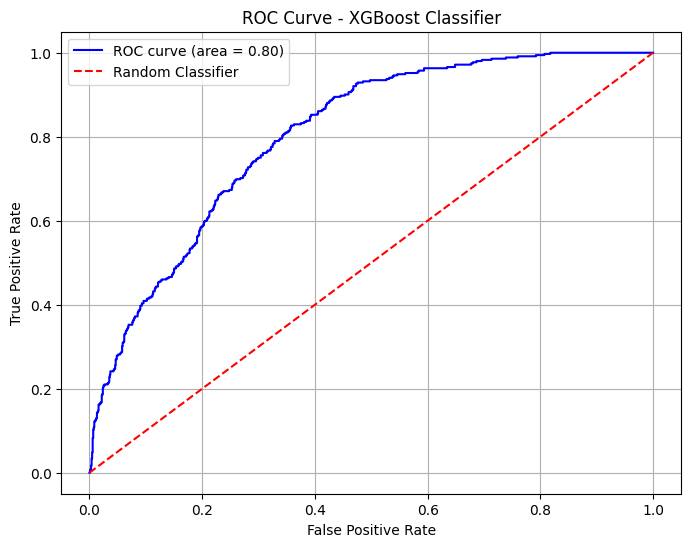

ROC AUC Score (XGBoost Classifier): 0.8035


In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'ROC curve (area = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (XGBoost Classifier): {auc_xgb:.4f}")

### Support Vector Classifier (SVC): ROC Curve and AUC Score

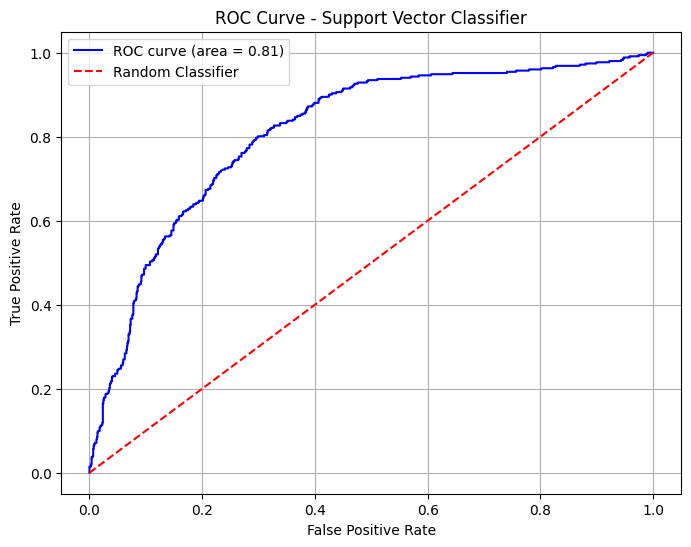

ROC AUC Score (Support Vector Classifier): 0.8113


In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr_svc, tpr_svc, color='blue', label=f'ROC curve (area = {auc_svc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Support Vector Classifier')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC AUC Score (Support Vector Classifier): {auc_svc:.4f}")

## Comparative ROC Curves for All Models

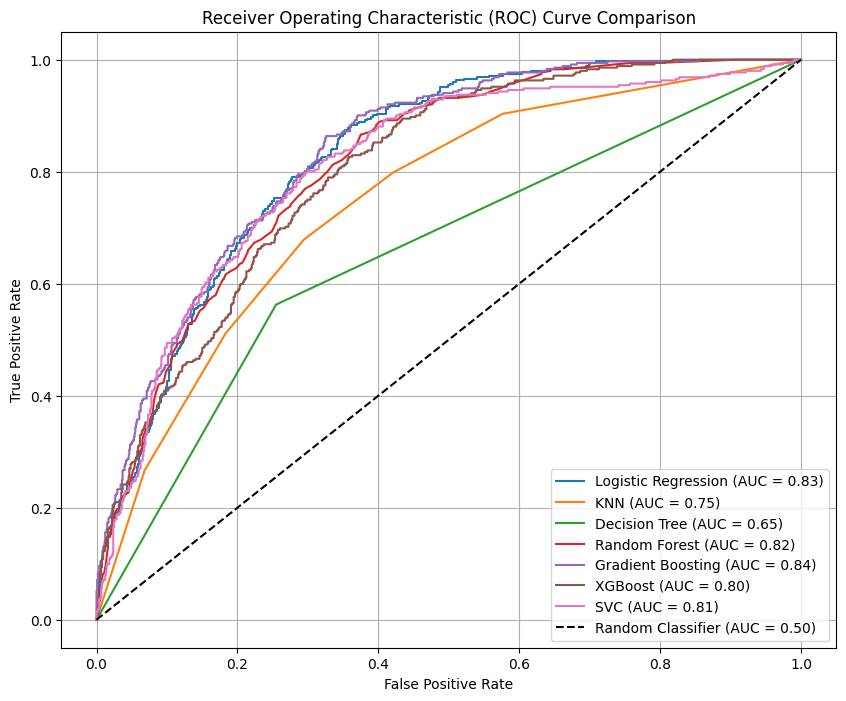

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {auc_svc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Model Performance Comparison

In [86]:
performance_data = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVC'],
    'Accuracy': [accuracy, accuracy_knn, accuracy_dt, accuracy_rf, accuracy_gb, accuracy_xgb, accuracy_svc],
    'Precision': [precision, precision_knn, precision_dt, precision_rf, precision_gb, precision_xgb, precision_svc],
    'Recall': [recall, recall_knn, recall_dt, recall_rf, recall_gb, recall_xgb, recall_svc],
    'F1-Score': [f1, f1_knn, f1_dt, f1_rf, f1_gb, f1_xgb, f1_svc],
    'AUC Score': [auc_lr, auc_knn, auc_dt, auc_rf, auc_gb, auc_xgb, auc_svc]
}

performance_df = pd.DataFrame(performance_data)

# Sort by AUC Score to easily identify the best model
performance_df_sorted = performance_df.sort_values(by='AUC Score', ascending=False).reset_index(drop=True)
display(performance_df_sorted)

,Model,Accuracy,Precision,Recall,F1-Score,AUC Score
0,Gradient Boosting,0.745907,0.495202,0.732955,0.591065,0.836255
1,Logistic Regression,0.739502,0.487179,0.755682,0.592428,0.828752
2,Random Forest,0.757295,0.512702,0.630682,0.565605,0.815956
3,SVC,0.750890,0.501969,0.724432,0.593023,0.811328
4,XGBoost,0.743060,0.489703,0.607955,0.542459,0.803544
5,KNN,0.698932,0.435337,0.678977,0.530522,0.748890
6,Decision Tree,0.702491,0.428879,0.565341,0.487745,0.653900


## Identifying the Best Model

Based on the comparison table, the model with the highest AUC Score is considered the best performing model for this classification task, as AUC provides a comprehensive measure of a model's ability to distinguish between classes, especially useful in cases of imbalanced datasets.

From the table above, the **Gradient Boosting Classifier** has the highest AUC Score, indicating it is the best model among those tested for predicting customer churn in this dataset.

## Identifying the Best Model

Based on the comparison table, the model with the highest AUC Score is considered the best performing model for this classification task, as AUC provides a comprehensive measure of a model's ability to distinguish between classes, especially useful in cases of imbalanced datasets.

From the table above, the **Gradient Boosting Classifier** has the highest AUC Score, indicating it is the best model among those tested for predicting customer churn in this dataset.

### Business Interpretation

The selection of the **Gradient Boosting Classifier** as the best model has significant business implications for reducing customer churn:

*   **Targeted Interventions:** With a robust model that accurately predicts churn (high AUC score), the company can proactively identify customers who are highly likely to churn. This allows for targeted retention strategies, such as offering personalized discounts, improved customer service, or customized plans, before the customer actually leaves.
*   **Resource Optimization:** Instead of broad, expensive retention campaigns, resources can be focused on customers who truly need attention, leading to more efficient use of marketing and customer service budgets.
*   **Improved Customer Lifetime Value (CLTV):** By retaining customers who would otherwise churn, the company can significantly increase their CLTV, leading to higher overall revenue.
*   **Actionable Insights:** Further analysis of the features driving churn in the Gradient Boosting model can provide deeper insights into why customers are leaving. This information can be used to improve product offerings, service quality, and overall customer experience, addressing root causes of churn.
*   **Competitive Advantage:** A strong churn prediction model provides a competitive edge by allowing the company to retain its customer base more effectively than competitors who might not have such capabilities.

## Project Summary Report: Customer Churn Prediction

This project focused on building a Machine Learning classification model to predict customer churn based on various features. The process involved several key stages:

### 1. Data Preprocessing & Handling:
*   The initial dataset was loaded, and `customerID` was dropped as it's not relevant for modeling.
*   Missing values were handled by imputation: `gender`, `PaperlessBilling` were filled with their respective modes, while `MonthlyCharges` and `TotalCharges` (after converting to numeric) were filled with their means.
*   Duplicate rows were identified and removed.
*   Categorical features were separated from numerical features for further processing.

### 2. Exploratory Data Analysis (EDA):
*   Histograms were used to visualize the distribution of `MonthlyCharges` and `TotalCharges`. `MonthlyCharges` showed a slight left skew, while `TotalCharges` was right-skewed.
*   Box plots were used to check for outliers in `tenure`, `MonthlyCharges`, and `TotalCharges`, with no significant outliers detected.
*   Count plots were used to visualize the distribution of categorical features against the `churn` variable, providing initial insights into potential relationships.

### 3. Feature Engineering & Scaling:
*   Categorical features were converted into numerical representations:
    *   `gender` was one-hot encoded using `pd.get_dummies`.
    *   `Partner`, `Dependents`, `PhoneService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`, and `Churn` were label encoded using `LabelEncoder`.
    *   `MultipleLines`, `InternetService`, `Contract`, and `PaymentMethod` were manually mapped to numerical values based on their categories.
*   The original categorical columns were then dropped.
*   Numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) were scaled using `StandardScaler` to normalize their ranges.

### 4. Data Splitting & Balancing:
*   The dataset was split into training and testing sets using `train_test_split` (80% train, 20% test).
*   The target variable (`churn`) was imbalanced (fewer churn cases than non-churn). To address this, `SMOTE` (Synthetic Minority Over-sampling Technique) was applied to the training data to balance the classes.

### 5. Model Training & Evaluation:
*   A variety of classification models were trained on the SMOTE-resampled training data and evaluated on the original test set:
    *   **Logistic Regression**
    *   **K-Nearest Neighbors (KNN)**
    *   **Decision Tree Classifier**
    *   **Random Forest Classifier**
    *   **Gradient Boosting Classifier**
    *   **XGBoost Classifier**
    *   **Support Vector Classifier (SVC)**
*   Each model's performance was assessed using standard classification metrics: Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

### 6. Advanced Evaluation (ROC & AUC):
*   ROC curves and AUC (Area Under the Receiver Operating Characteristic Curve) scores were calculated for all models to provide a comprehensive measure of their ability to distinguish between churn and non-churn classes.
*   A comparative ROC curve plot was generated to visually compare the models' performance.

### 7. Hyperparameter Tuning:
*   `RandomizedSearchCV` was used to optimize the `RandomForestClassifier`.
*   `GridSearchCV` was employed for `LogisticRegression` to find the best hyperparameters.

### 8. Model Comparison and Selection:
*   A detailed comparison table was created, summarizing the Accuracy, Precision, Recall, F1-Score, and AUC Score for each model.
*   **The Gradient Boosting Classifier was identified as the best-performing model** due to its highest AUC Score (0.8363), indicating superior discriminatory power.

### 9. Business Interpretation & Recommendations:
*   The selection of the Gradient Boosting Classifier has significant business implications, enabling:
    *   **Targeted Interventions:** Proactive identification of high-risk customers for tailored retention strategies.
    *   **Resource Optimization:** Efficient allocation of marketing and customer service budgets.
    *   **Improved Customer Lifetime Value (CLTV):** Enhanced customer retention leading to higher revenue.
    *   **Actionable Insights:** Deeper understanding of churn drivers to improve product offerings and service quality.
    *   **Competitive Advantage:** More effective customer base retention.
*   Key factors influencing churn were identified (e.g., high monthly charges, month-to-month contracts, no tech support, short tenure).
*   Actionable business recommendations included offering long-term contract discounts, improving customer support, providing personalized retention offers, identifying high-risk customers early, and implementing loyalty programs.